<a href="https://colab.research.google.com/github/PVC2020/Estatistica_basica/blob/main/estat_stica_computacional_em_python_capitulo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estatística Computacional em Python Capitulo 1

Curso de estatistica prof Daniel Furtado Ferreira UFLA

https://des.ufla.br/~danielff/meusarquivospdf/ECPython.pdf


Estatística Básica/Pedro A. Morettin, Wilton O. Bussab. –
6. ed. – São Paulo : Saraiva, 2010

https://www.professores.uff.br/jutriavaldes/wp-content/uploads/sites/196/2019/08/Book_EstatBas-Morettin-Bussab.pdf


Estatística básica com suporte computacional em R
[livro eletrônico] / Francisco Louzada, Paulo
Henrique Ferreira, Pedro Luiz Ramos

https://cemeai.icmc.usp.br/wp-content/uploads/2026/07/Livro-Estatistica-Basica-R-Portugues.pdf

In [ ]:
#instalando as bibliotecas de ambiente

!pip install numpy
!pip install sympy
!pip install PIL
!pip install jupyter
!pip install matplotlib
#importar as libraries
import math
import numpy
import sympy
import PIL
import jupyter
import matplotlib

ERROR: Could not find a version that satisfies the requirement PIL (from versions: none)
ERROR: No matching distribution found for PIL
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 66.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 72.9 MB/s eta 0:00:00


In [ ]:
# Programa ilustrativo de operações elementares
# em Python
print(1 + 2 + 3) # soma dos 3 primeiros inteiros
print(3**10 - 1 + 8)
print(6 / 5 + 0.5**4)


6
59056
1.2625


In [ ]:
print((6-4j)**2)
# problema matematico complexo

(20-48j)


## 1. Classificação das Variáveis

Antes de qualquer análise, precisamos classificar os dados. O tipo da variável dita qual técnica estatística ou gráfico utilizaremos.

**1. Variáveis Qualitativas (Categóricas)**: Representam atributos ou qualidades.
*   **Nominal**: Não existe ordem ou hierarquia. *(Ex: Região de procedência, Cor do solo)*
*   **Ordinal**: Existe uma ordem lógica. *(Ex: Grau de instrução, Classe social, Nível de compactação do solo)*

**2. Variáveis Quantitativas (Numéricas)**: Representam quantidades ou medidas.
*   **Discreta**: Fruto de contagem, números inteiros. *(Ex: Número de filhos, Quantidade de plantas por m²)*
*   **Contínua**: Fruto de mensuração, aceita casas decimais. *(Ex: Peso, Estatura, Produtividade em ton/ha)*

> 💡 **Nota sobre Variáveis Dicotômicas (Binárias)**: É um caso especial de variável qualitativa com apenas duas saídas (ex: Sucesso/Fracasso, Vivo/Morto). Na modelagem de dados, é muito útil transformá-las em números (0 e 1) para facilitar os cálculos.

## Tipos de Variáveis
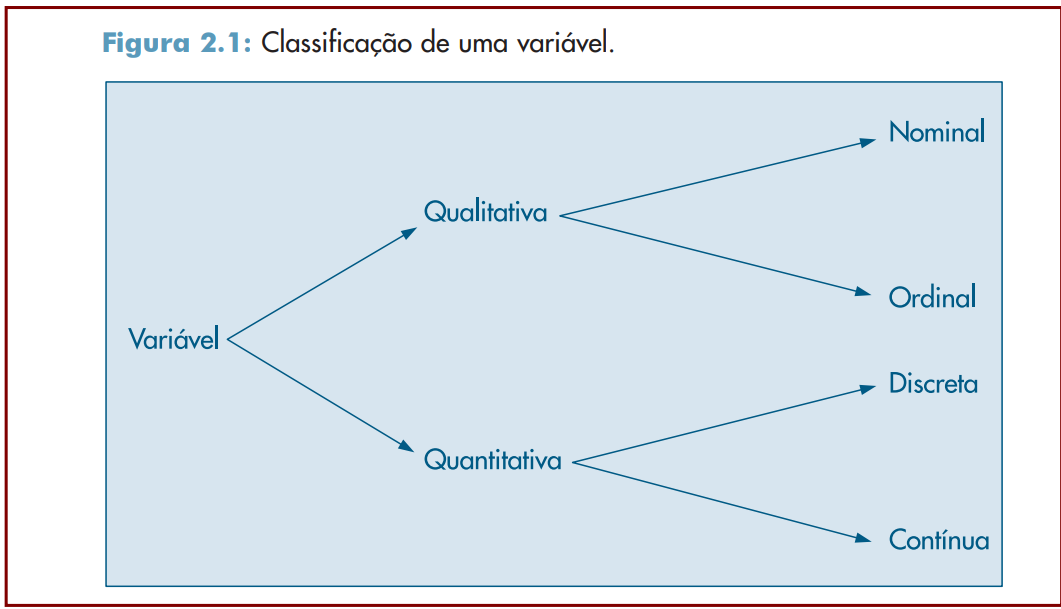




In [ ]:
import pandas as pd
#importando a bibioteca pandas e dando um "apelido" de pd

# Criando um DataFrame com exemplos de cada tipo
dados = pd.DataFrame({
    'regiao': ['Norte', 'Sul', 'Sudeste', 'Sul'], # Qualitativa Nominal (texto/object)
    'classe_social': ['Baixa', 'Média', 'Alta', 'Média'], # Qualitativa Ordinal (texto/category)
    'num_filhos': [0, 2, 1, 3], # Quantitativa Discreta (int64)
    'peso_kg': [65.5, 80.2, 72.1, 91.0], # Quantitativa Contínua (float64)
    'sucesso_tratamento': ['Sim', 'Não', 'Sim', 'Sim'] # Dicotômica
})

# 1. Transformando texto em Categoria Ordinal (para o Python entender a hierarquia)
dados['classe_social'] = pd.Categorical(
    dados['classe_social'],
    categories=['Baixa', 'Média', 'Alta'],
    ordered=True
)

# 2. Transformando a Dicotômica em 0 e 1 (True e False também funcionam)
dados['sucesso_tratamento'] = dados['sucesso_tratamento'].map({'Sim': 1, 'Não': 0})

# Visualizando os tipos de dados (o equivalente ao str() do R)
print("--- Tipos das Variáveis no Pandas ---")
print(dados.dtypes)

##object: É como o Python chama variáveis de texto (Nominais).
#category: Variável categórica (usamos para garantir a ordem da Ordinal).
#int64: Números inteiros (Discretas).
#float64: Números com casas decimais (Contínuas).

--- Tipos das Variáveis no Pandas ---
regiao                  object
classe_social         category
num_filhos               int64
peso_kg                float64
sucesso_tratamento       int64
dtype: object


## 2. Carregando e Limpando o Conjunto de Dados

Para analisar uma tabela real, o primeiro passo é importar os dados para um `DataFrame` (a estrutura de dados tabular do Pandas, equivalente ao `data.frame` do R).

**Pontos de atenção na importação:**
1. **Dados Faltantes (Missing Values):** Em tabelas reais, dados ausentes podem vir como espaços em branco, `NA`, `.` ou `-`. Precisamos avisar o Python para interpretar isso como um dado nulo (`NaN`), caso contrário, ele transformará uma coluna numérica em texto.
2. **Tipos de Variáveis:** Sempre verifique se o Python identificou corretamente quem é número e quem é texto após a leitura.

> 💡 **Dica:** O comando `df.head()` no Python é idêntico ao `head(df)` no R: serve para espiar as primeiras linhas da tabela. O `df.info()` equivale ao `str(df)` do R.

In [ ]:
import pandas as pd
import io

# Simulando um arquivo CSV com os 10 primeiros registros da tabela
# Note que o N de filhos vazio está representado por um traço "-"
dados_csv = """id,estado_civil,grau_instrucao,num_filhos,salario,idade_anos,idade_meses,regiao
1,solteiro,ensino fundamental,-,4.00,26,3,interior
2,casado,ensino fundamental,1,4.56,32,10,capital
3,casado,ensino fundamental,2,5.25,36,5,capital
4,solteiro,ensino médio,-,5.73,20,10,outra
5,solteiro,ensino fundamental,-,6.26,40,7,outra
6,casado,ensino fundamental,0,6.66,28,8,interior
7,solteiro,ensino fundamental,-,6.86,41,8,interior
8,solteiro,ensino fundamental,-,7.39,43,4,capital
9,casado,ensino médio,1,7.59,34,10,capital
10,solteiro,ensino médio,-,7.44,23,6,outra
"""

# Lendo os dados e avisando que o traço "-" significa dado faltante (NaN)
df_empregados = pd.read_csv(io.StringIO(dados_csv), na_values=['-'])

# Visualizando as primeiras linhas (igual ao head() do R)
display(df_empregados.head())

print("\n--- Informações da Tabela (Estrutura e Dados Faltantes) ---")
# O info() mostra o tipo de cada coluna e quantos dados não-nulos existem
df_empregados.info()

display(df_empregados[['num_filhos','salario','idade_anos','idade_meses']].describe())
# esse comando describe mostra a estatistica dos valores no caso eu escolhi as colunas numericas . ela me mostra contagem,média geometrica, desvio padrão, minimo, 1,2 e3 quartil e maximo

,id,estado_civil,grau_instrucao,num_filhos,salario,idade_anos,idade_meses,regiao
0,1,solteiro,ensino fundamental,NaN,4.00,26,3,interior
1,2,casado,ensino fundamental,1.0,4.56,32,10,capital
2,3,casado,ensino fundamental,2.0,5.25,36,5,capital
3,4,solteiro,ensino médio,NaN,5.73,20,10,outra
4,5,solteiro,ensino fundamental,NaN,6.26,40,7,outra



--- Informações da Tabela (Estrutura e Dados Faltantes) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              10 non-null     int64  
 1   estado_civil    10 non-null     object 
 2   grau_instrucao  10 non-null     object 
 3   num_filhos      4 non-null      float64
 4   salario         10 non-null     float64
 5   idade_anos      10 non-null     int64  
 6   idade_meses     10 non-null     int64  
 7   regiao          10 non-null     object 
dtypes: float64(2), int64(3), object(3)
memory usage: 772.0+ bytes


,num_filhos,salario,idade_anos,idade_meses
count,4.000000,10.000000,10.000000,10.000000
mean,1.000000,6.174000,32.300000,7.100000
std,0.816497,1.255337,7.902883,2.558211
min,0.000000,4.000000,20.000000,3.000000
25%,0.750000,5.370000,26.500000,5.250000
50%,1.000000,6.460000,33.000000,7.500000
75%,1.250000,7.257500,39.000000,9.500000
max,2.000000,7.590000,43.000000,10.000000


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 3. Distribuições de Frequências

A distribuição de frequências é a forma mais primária de resumir o comportamento de uma variável qualitativa ou quantitativa discreta. Ela expõe quantas vezes cada categoria ocorreu e sua representatividade no todo, sendo essencial para comparar amostras de tamanhos diferentes.

**Fórmulas e Notações:**
*   **Frequência Absoluta ($n_i$):** É a contagem direta de ocorrências de uma categoria.
*   **Frequência Relativa ou Proporção ($f_i$):** É a fração da categoria em relação ao total ($n$).  
    $$f_i = \frac{n_i}{n}$$
*   **Porcentagem:** A proporção multiplicada por 100 ($100 \times f_i$).

In [ ]:
import pandas as pd

# Simulando a coluna "Grau de instrução" com os totais exatos do livro (n=36)
dados_instrucao = (['Fundamental'] * 12) + (['Médio'] * 18) + (['Superior'] * 6)
df_mb = pd.DataFrame({'grau_instrucao': dados_instrucao})

# 1. Frequência Absoluta (ni)
freq_absoluta = df_mb['grau_instrucao'].value_counts()

# 2. Frequência Relativa (fi) -> O parâmetro normalize=True faz a divisão pelo total automaticamente
freq_relativa = df_mb['grau_instrucao'].value_counts(normalize=True)

# 3. Montando a Tabela 2.2 final
tabela_frequencia = pd.DataFrame({
    'Frequência (ni)': freq_absoluta,
    'Proporção (fi)': freq_relativa,
    'Porcentagem (%)': freq_relativa * 100
})

# O value_counts ordena do maior para o menor por padrão.
# Usamos o reindex para forçar a ordenação ordinal do livro.
ordem_categorias = ['Fundamental', 'Médio', 'Superior']
tabela_frequencia = tabela_frequencia.reindex(ordem_categorias)

print("--- Distribuição de Frequências (Grau de Instrução) ---")
# O .round(4) iguala a formatação decimal à do livro
display(tabela_frequencia.round(4))

--- Distribuição de Frequências (Grau de Instrução) ---


,Frequência (ni),Proporção (fi),Porcentagem (%)
grau_instrucao,,,
Fundamental,12,0.3333,33.3333
Médio,18,0.5000,50.0000
Superior,6,0.1667,16.6667


## 4. Distribuição de Frequências para Variáveis Contínuas

Quando lidamos com variáveis contínuas (como Salário, Peso, Altura), quase todos os valores são únicos. Fazer uma tabela de frequência simples geraria uma linha para cada observação, o que não resume nada. A solução é **agrupar os dados em intervalos de classes (bins)**.

**Conceitos Chave:**
*   **Notação de Intervalo:** O padrão $[a, b)$ ou $a \vdash b$ significa que o intervalo **inclui** o valor $a$ (fechado à esquerda) e **exclui** o valor $b$ (aberto à direita).
*   **Perda de Informação vs. Resumo:** Ao agrupar dados (ex: saber que há 8 pessoas ganhando entre 12 e 16 salários), perdemos o valor exato de cada salário. Em cálculos futuros, assumiremos que todos os valores dessa classe equivalem ao **ponto médio** do intervalo (ex: 14).
*   **Regra de Ouro:** Recomenda-se utilizar entre 5 e 15 classes de mesma amplitude (tamanho). Poucas classes escondem os detalhes; muitas classes dificultam a visualização.

In [ ]:
import pandas as pd
import numpy as np

# Inserindo os 36 salários reais da Companhia MB (Tabela 2.1)
salarios = [4.00, 4.56, 5.25, 5.73, 6.26, 6.66, 6.86, 7.39, 7.44, 7.59,
            8.12, 8.46, 8.74, 8.95, 9.13, 9.35, 9.77, 9.80, 10.53, 10.76,
            11.06, 11.59, 12.00, 12.79, 13.23, 13.60, 13.85, 14.69, 14.71,
            15.99, 16.22, 16.61, 17.26, 18.75, 19.40, 23.30]

df_continuo = pd.DataFrame({'salario': salarios})

# 1. Definindo os limites (bins) das classes: de 4 até 24, pulando de 4 em 4
limites = [4, 8, 12, 16, 20, 24]

# 2. pd.cut() categoriza os valores contínuos nas faixas estipuladas.
# O argumento 'right=False' garante a notação [a, b), ou seja, fechado à esquerda e aberto à direita.
df_continuo['faixa_salarial'] = pd.cut(df_continuo['salario'], bins=limites, right=False)

# 3. Calculando frequências e porcentagens
freq_abs = df_continuo['faixa_salarial'].value_counts(sort=False) # sort=False mantém a ordem dos intervalos numéricos
freq_rel = df_continuo['faixa_salarial'].value_counts(sort=False, normalize=True)

# 4. Montando a Tabela 2.4
tabela_salarios = pd.DataFrame({
    'Frequência (ni)': freq_abs,
    'Porcentagem (%)': freq_rel * 100
})

print("--- Distribuição de Frequências por Faixa de Salário ---")
display(tabela_salarios.round(2))

--- Distribuição de Frequências por Faixa de Salário ---


,Frequência (ni),Porcentagem (%)
faixa_salarial,,
"[4, 8)",10,27.78
"[8, 12)",12,33.33
"[12, 16)",8,22.22
"[16, 20)",5,13.89
"[20, 24)",1,2.78


## 5. Visualização de Dados (Gráficos e Ramos)

A representação gráfica permite identificar rapidamente o comportamento, a variabilidade e a assimetria da distribuição dos dados.

**1. Para Variáveis Qualitativas (Categorias):**
*   **Gráfico de Barras:** Compara a magnitude (frequência absoluta ou relativa) entre as categorias. As barras são separadas.
*   **Gráfico de Setores ("Pizza"):** Ideal para mostrar a composição de partes de um todo (porcentagens). O círculo representa 100%.

**2. Para Variáveis Quantitativas (Números):**
*   **Histograma:** Usado para dados contínuos (ou discretos com muitos valores). São barras contíguas (coladas) onde a **área** do retângulo é proporcional à frequência da classe. Ele agrupa os dados em intervalos (bins).
*   **Ramo-e-Folhas (Stem-and-Leaf):** Uma alternativa clássica ao histograma. A grande vantagem é que ele mostra a forma da distribuição (onde os dados se concentram) **sem perder os valores originais**. O número é dividido: a parte principal forma o "ramo" e os últimos dígitos formam as "folhas".

/tmp/ipykernel_2963/3227424972.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_qualitativo, x='grau_instrucao',


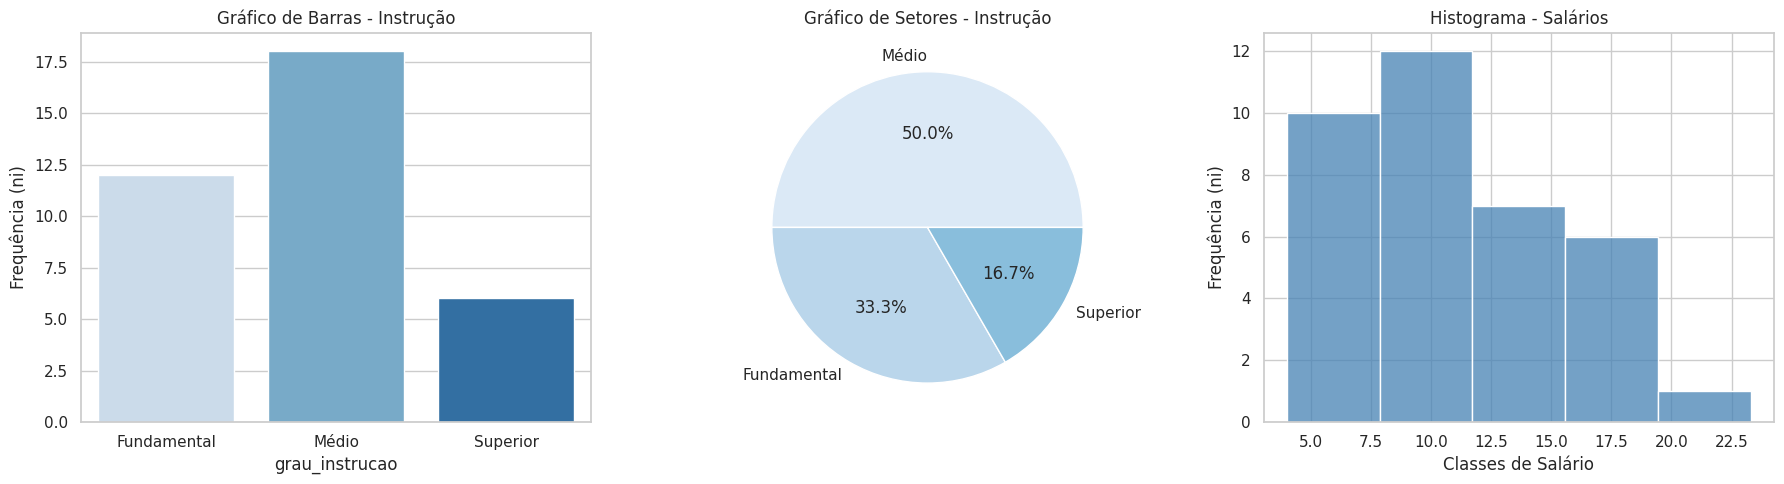


--- Ramo-e-Folhas (Salários) ---
 4 | 00 56
 5 | 25 73
 6 | 26 66 86
 7 | 39 44 59
 8 | 12 46 74 95
 9 | 13 35 77 80
10 | 53 76
11 | 06 59
12 | 00 79
13 | 23 60 85
14 | 69 71
15 | 99
16 | 22 61
17 | 26
18 | 75
19 | 40
23 | 30


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos para ficarem mais profissionais
sns.set_theme(style="whitegrid")

# --- DADOS ---
# Recriando os dados para os exemplos
dados_instrucao = (['Fundamental'] * 12) + (['Médio'] * 18) + (['Superior'] * 6)
df_qualitativo = pd.DataFrame({'grau_instrucao': dados_instrucao})

salarios = [4.00, 4.56, 5.25, 5.73, 6.26, 6.66, 6.86, 7.39, 7.44, 7.59,
            8.12, 8.46, 8.74, 8.95, 9.13, 9.35, 9.77, 9.80, 10.53, 10.76,
            11.06, 11.59, 12.00, 12.79, 13.23, 13.60, 13.85, 14.69, 14.71,
            15.99, 16.22, 16.61, 17.26, 18.75, 19.40, 23.30]

# Criando a área do gráfico (1 linha, 3 colunas) para plotar tudo junto
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gráfico de Barras (Qualitativa)
sns.countplot(data=df_qualitativo, x='grau_instrucao',
              order=['Fundamental', 'Médio', 'Superior'],
              ax=eixos[0], palette="Blues")
eixos[0].set_title('Gráfico de Barras - Instrução')
eixos[0].set_ylabel('Frequência (ni)')

# 2. Gráfico de Setores / Pizza (Qualitativa)
contagem = df_qualitativo['grau_instrucao'].value_counts()
eixos[1].pie(contagem, labels=contagem.index, autopct='%1.1f%%', colors=sns.color_palette("Blues"))
eixos[1].set_title('Gráfico de Setores - Instrução')

# 3. Histograma (Quantitativa)
# O KDE=False desativa a linha de tendência. Bins define o número de classes/faixas.
sns.histplot(salarios, bins=5, ax=eixos[2], color='steelblue')
eixos[2].set_title('Histograma - Salários')
eixos[2].set_xlabel('Classes de Salário')
eixos[2].set_ylabel('Frequência (ni)')

plt.tight_layout()
plt.show()

# --- BÔNUS: Ramo e Folhas ---
# O Python não tem uma função nativa famosa para Ramo e Folhas, pois o Histograma o substituiu na prática.
# Mas podemos criar um algoritmo simples para reproduzir a Figura 2.9 do livro:
print("\n--- Ramo-e-Folhas (Salários) ---")
ramos = {}
for s in salarios:
    ramo = int(s) # A parte inteira é o ramo
    folha = int(round((s - ramo) * 100)) # Os decimais são a folha
    ramos.setdefault(ramo, []).append(f"{folha:02d}")

for r in sorted(ramos.keys()):
    print(f"{r:2d} | {' '.join(ramos[r])}")